Material for the book Probability and Statistics for Data Science. A free preprint, videos, code, slides and solutions to exercises are available at https://www.ps4ds.net/

Autocorrelation of the temperature in Oxford.\
Topics and relevant videos: [Overview of correlation](https://www.youtube.com/watch?v=LMKnAVH-J3U), [correlation and covariance](https://www.youtube.com/watch?v=LMKnAVH-J3U)

Author: Carlos Fernandez-Granda\
Data source: http://www.metoffice.gov.uk/research/climate/maps-and-data/

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

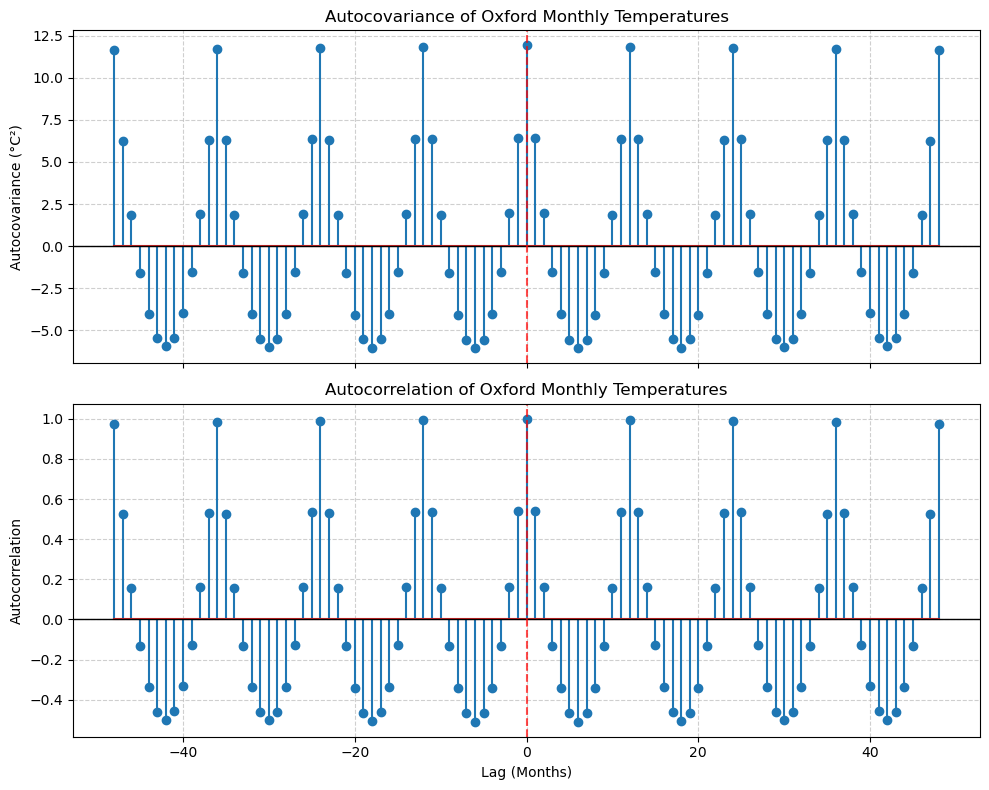

In [4]:
temperatures = np.load("../data/oxford_temperatures.npy")

# Demean the series (subtract mean for covariance calculation)
n = len(temperatures)
temp_demeaned = temperatures - np.mean(temperatures)

# Compute full autocovariance (lags from -(n-1) to +(n-1))
# Mode 'full' computes cross-correlation over all overlapping steps
autocovariance_full = np.correlate(temp_demeaned, temp_demeaned, mode="full") / n

# Compute full autocorrelation (normalize by variance, i.e., autocovariance at lag 0, which is at the n-1th entry)
autocorrelation_full = autocovariance_full / autocovariance_full[n - 1]

# Define lag range (-max_lags to +max_lags), setting equal to 4 years 
max_lags = 4*12
lags = np.arange(-max_lags, max_lags + 1)

# Extract values corresponding to the target lag range
zero_lag_idx = n - 1  # Index where lag = 0 in full correlation array
slice_indices = slice(zero_lag_idx - max_lags, zero_lag_idx + max_lags + 1)

autocov = autocovariance_full[slice_indices]
autocorr = autocorrelation_full[slice_indices]

# Plot Autocovariance and Autocorrelation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Autocovariance Plot
ax1.stem(lags, autocov)
ax1.axhline(0, color="black", linewidth=1)
ax1.axvline(0, color="red", linestyle="--", alpha=0.7)
ax1.set_title("Autocovariance of Oxford Monthly Temperatures")
ax1.set_ylabel("Autocovariance (°C²)")
ax1.grid(True, linestyle="--", alpha=0.6)

# Autocorrelation Plot
ax2.stem(lags, autocorr)
ax2.axhline(0, color="black", linewidth=1)
ax2.axvline(0, color="red", linestyle="--", alpha=0.7)
ax2.set_title("Autocorrelation of Oxford Monthly Temperatures")
ax2.set_xlabel("Lag (Months)")
ax2.set_ylabel("Autocorrelation")
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()